In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, roc_auc_score, confusion_matrix
)

from tensorflow import keras
from tensorflow.keras import layers

In [4]:
# Preprocessing
df = pd.read_csv('Telco-Customer-Churn.csv')

# Removing it as it is just an identifier
X = df.drop(['customerID', 'Churn'], axis=1)

y = df['Churn'].map({'No':0, 'Yes':1}) # Important to convert to 0-1

# Converting total charges to numeric
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X['TotalCharges'] = X['TotalCharges'].fillna(X['TotalCharges'].median())

# Encoding the categorical features
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Scale Features

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [6]:
# Balancing the class weights

neg, pos = np.bincount(y_train)
total = neg + pos
class_weight = {0: total/(2*neg), 1: total/(2*pos)}
print(f'Class weights: {class_weight}')

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


In [7]:
# Building the Model

model = keras.Sequential([
    
    # Input layer
    # shape = number of features (columns) in X_train_s
    # Example: If X_train_s has 20 columns, input shape = (20,)
    layers.Input(shape=(X_train_s.shape[1],)),
    
    # First hidden layer
    # 32 neurons, each connected to every input feature
    # ReLU activation:
    #   f(x) = max(0, x)
    # Helps the model learn complex patterns and avoids vanishing gradients.
    layers.Dense(32, activation='relu'),
    
    # Dropout layer
    # Randomly disables 30% of neurons during training
    # Prevents overfitting (memorising the training data).
    layers.Dropout(0.3),
    
    # Second hidden layer
    # Takes the 32 outputs from the previous layer and
    # learns higher-level features using 16 neurons.
    layers.Dense(16, activation='relu'),
    
    # Another dropout layer
    # Randomly disables 20% of neurons during training
    # Adds more protection against overfitting.
    layers.Dropout(0.2),
    
    # Output layer
    # Only 1 neuron because this is Binary Classification.
    # Sigmoid activation converts the output into a probability (0 to 1).
    # Example:
    #   0.92 -> 92% chance of Class 1
    #   0.18 -> 18% chance of Class 1
    # Usually:
    #   Probability >= 0.5 -> Predict Class 1
    #   Probability < 0.5  -> Predict Class 0
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
# This tells the neural network:
# 1. How to update its weights (optimizer)
# 2. How to measure its mistakes (loss function)
# 3. Which metrics to display during training (metrics)

model.compile(
    
    # Optimizer
    # Adam (Adaptive Moment Estimation) is one of the most popular optimizers.
    # It automatically adjusts the learning rate for each parameter,
    # helping the model converge faster and more efficiently.
    optimizer='adam',
    
    # Loss Function
    # Binary Crossentropy is used for Binary Classification problems
    # (where the target has only two classes: 0 and 1).
    # It measures how far the predicted probability is from the actual label.
    # Lower loss = Better predictions.
    loss='binary_crossentropy',
    
    # Metrics to monitor while training
    metrics=[
        
        # Accuracy
        # Percentage of correctly classified samples.
        # Formula:
        # Accuracy = (Correct Predictions / Total Predictions)
        'accuracy',
        
        # Recall (Sensitivity)
        # Measures how many actual positive cases the model correctly identifies.
        # Formula:
        # Recall = TP / (TP + FN)
        # High recall means the model misses fewer positive cases.
        keras.metrics.Recall(name='recall'),
        
        # AUC (Area Under the ROC Curve)
        # Measures how well the model separates the two classes.
        # Range:
        # 0.5 -> Random guessing
        # 1.0 -> Perfect classifier
        # Higher AUC indicates better overall classification performance.
        keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ dense (Dense)            │ (None, 32)        │       992 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout (Dropout)        │ (None, 32)        │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_1 (Dense)          │ (None, 16)        │       528 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout_1 (Dropout)      │ (None, 16)        │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_2 (Dense)          │ (None, 1)         │        17 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Training the model

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7173 - auc: 0.6845 - loss: 0.7001 - recall: 0.3867 - val_accuracy: 0.7036 - val_auc: 0.7910 - val_loss: 0.5464 - val_recall: 0.7559
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7056 - auc: 0.7918 - loss: 0.5497 - recall: 0.7533 - val_accuracy: 0.6948 - val_auc: 0.8104 - val_loss: 0.5461 - val_recall: 0.8068
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7171 - auc: 0.8128 - loss: 0.5283 - recall: 0.7933 - val_accuracy: 0.6939 - val_auc: 0.8151 - val_loss: 0.5475 - val_recall: 0.8102
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7249 - auc: 0.8281 - loss: 0.5080 - recall: 0.8058 - val_accuracy: 0.7072 - val_auc: 0.8177 - val_loss: 0.5405 - val_recall: 0.8068
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7384 - auc: 0.8295 - loss: 0.5054 - recall: 0.8083 - val_accuracy: 0.6877 - val_auc: 0.8195 - val_loss: 0.5532 - val_recall: 0.8373
Epoch 6/50

In [11]:
# Evaluating the test set

y_proba_nn = model.predict(X_test_s).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print("Neural Network Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_nn):.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network Results:
Accuracy:  0.7303
Recall:    0.8048
Precision: 0.4951
AUC:       0.8337


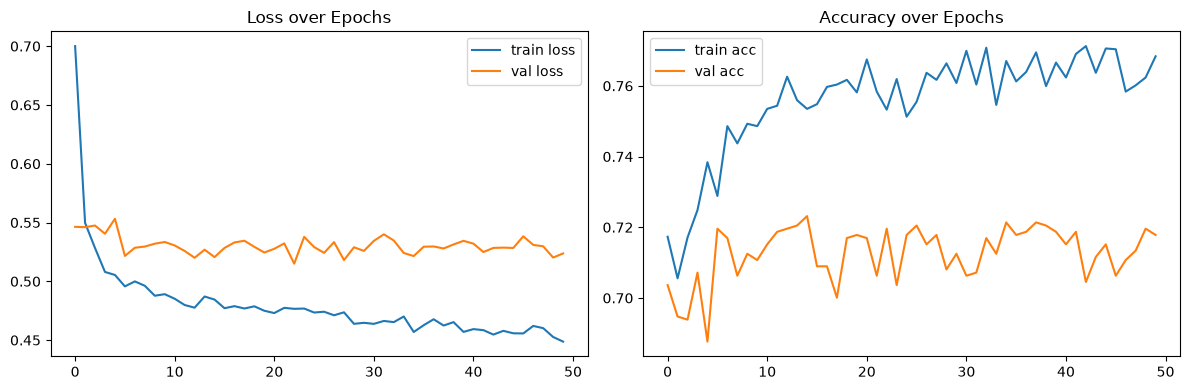

In [15]:
# Plotting training history (loss + accuracy curves)

from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2, figsize = (12, 4))

axes[0].plot(history.history['loss'], label = 'train loss')
axes[0].plot(history.history['val_loss'], label = 'val loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label = 'train acc')
axes[1].plot(history.history['val_accuracy'], label = 'val acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('nn_training_history.png')
plt.show()

In [16]:
# Saving the model

model.save('churn_nn_model.keras')
joblib.dump(scaler, 'churn_nn_scaler.pkl')

['churn_nn_scaler.pkl']